In [1]:
# Import fetch_california_housing dataset from sklearn
# Check and handle the inconsistencies
    # - In HouseAge fill null values with mean
    # - In population fill null values with median
# Encode the catergorical columns
# Seperate X and y
# Train test and split
# Scale the features

In [72]:
import pandas as pd # Used for data manipulation
import numpy as np # Used for numerical operations
import seaborn as sns # Used for visualization
import matplotlib.pyplot as plt # Used for visualization

from sklearn.datasets import fetch_california_housing
# Used to import dataset as a bunch or function
from sklearn.preprocessing import StandardScaler
# Used for Scaling the features
from sklearn.model_selection import train_test_split
# Used to select the type of splitting
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# Used for selecting each linear model
from sklearn.metrics import mean_squared_error, r2_score
# Used for metrics, to evaluate the model

In [74]:
data = fetch_california_housing()
# Store values of the dataset as a bunch or function
df = pd.DataFrame(data.data,columns = data.feature_names)
# Conver the dataset into a Pandas dataframe, data are the values stored, and feature_names are the names of the columns
df['Price'] = data.target
# Target is the output variable or dependent variable
df.head()
# Top 5 rows of the dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [76]:
# Check and handle null values
num_cols = df.select_dtypes(include=['float64']).columns
# Selects the values from the columns which have float datatype
df = df[num_cols].fillna(df[num_cols].median())
# Replace the null values of the columns with median

In [78]:
# Check and handle outliers
for num in num_cols:
    q1 = df[num].quantile(0.25) # Q1 is the first quarter
    q3 = df[num].quantile(0.75) # Q3 is the third quarter
    iqr = q3 - q1 # Interquartile range calcualtion
    ul = q3 + (1.5*iqr) # Upper limit of the data
    ll = q1 - (1.5*iqr) # Lower limit of the range
    outliers = df[(df[num] < ll) | (df[num] > ul)] # Values less than lower limit and greater than upper limit are outliers
    print(f'The outliers in the col {num}: {len(outliers)}') # Visulaizing the number of outliers
    df = df[(df[num] >= ll) & (df[num] <= ul)] # Cleaning the outliers

The outliers in the col MedInc: 681
The outliers in the col HouseAge: 0
The outliers in the col AveRooms: 439
The outliers in the col AveBedrms: 1116
The outliers in the col Population: 1063
The outliers in the col AveOccup: 528
The outliers in the col Latitude: 0
The outliers in the col Longitude: 0
The outliers in the col Price: 581


In [80]:
# Feature Engineering
df.columns

df['RoomsPerHousehold'] = (df['AveRooms'] / df['AveOccup'])
# Creates column rooms per household by dividing average rooms per occupied rooms
df['BedroomRatio'] = (df['AveBedrms'] / df['AveOccup'])
# Bedroom ratio will be given by average bedrooms divided total occupied rooms
df['PopulationDensity'] = df['Population'] / df['AveOccup']
# Population density column is also created 

# Feature Engineering helps to make the more reliable and consistent for better prediction

In [82]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,RoomsPerHousehold,BedroomRatio,PopulationDensity
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.421147,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.495575,259.0
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697,2.225182,0.515738,193.0
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992,2.317185,0.446984,514.0
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414,2.682800,0.593777,647.0


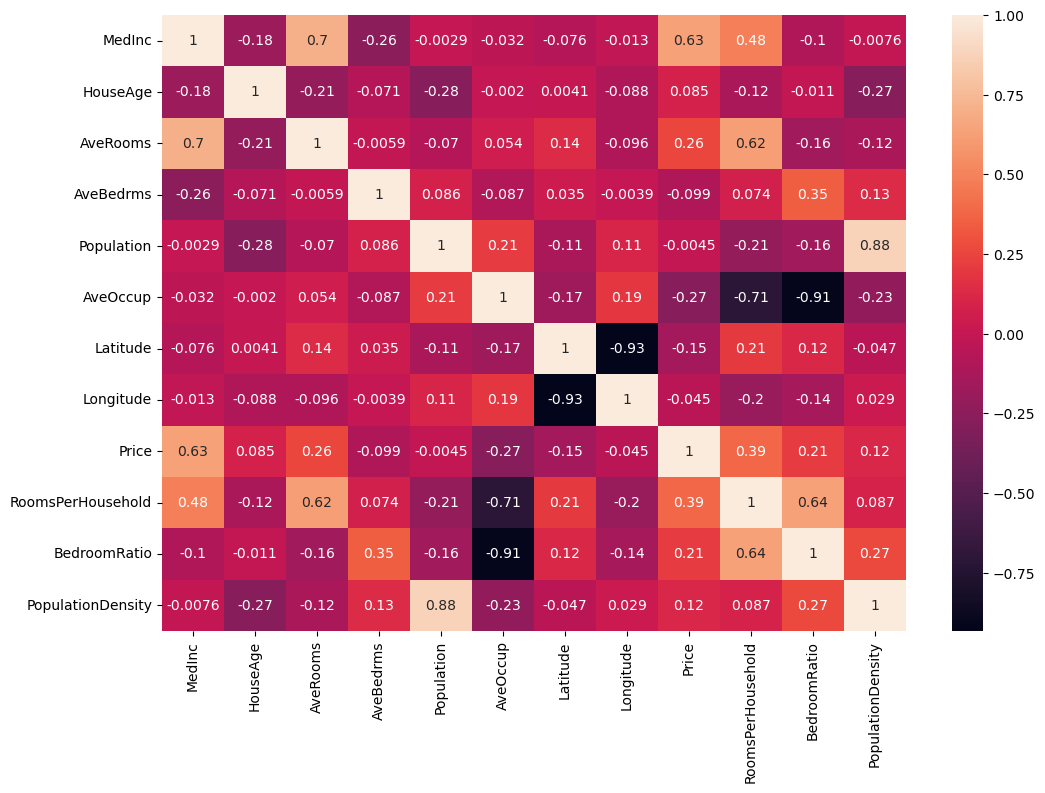

In [84]:
# Check for correlation matrix
# Create a heatmap to check the correlation for price between different variables
plt.figure(figsize=[12,8]) # Adjusts the size of the heatmap
sns.heatmap(df.corr(),annot=True) # Creates a heatmap 
plt.show() # Displays the result

In [88]:
# Split features and targets
X = df.drop('Price',axis=1) # Select everything except price
y = df['Price'] # Select price to predict

In [92]:
# Train_Test_Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=22)
# Create 4 datasets 2 for training and 2 for testing. 
# In train test split choose 4 params: 1. Training data 2. Testing data 3. Testing size 4. Random State

In [98]:
# Scale your features
scale = StandardScaler() # Use standard scaler to scale the features
X_train = scale.fit_transform(X_train) # Fit and transform training data
X_test = scale.transform(X_test) # Transform only testing data

In [ ]:
# Create three regression models
# Linear Regression
# Ridge Regression
# Lasso Regression

In [101]:
# linear Regression
# Create a Linear regression model
lr = LinearRegression()
# Train your training data
lr.fit(X_train,y_train)
# Predict on your testing data
lr_predict = lr.predict(X_test)

In [105]:
# Ridge regression
ridge = Ridge(alpha = 1.0) # alpha is lambda
ridge.fit(X_train,y_train)
ridge_predict = ridge.predict(X_test)

# Ridge regression would reduce variance hence reducing collinearity and reducing overfititng.
# Shrinks the coefficients 

In [107]:
# Lasso regression
lasso = Lasso(alpha = 0.1) # alpha is lambda
lasso.fit(X_train,y_train)
lasso_predict = lasso.predict(X_test)

# Lasso can remove irrelevant featuresby making coeffiecients zero.

In [109]:
# evaluation Metrics

def evaluate(y_true,y_pred):
    r2 = r2_score(y_true,y_pred)
    mse = mean_squared_error(y_true,y_pred)

    return r2,mse

In [113]:
# Compare the models
lr_metrics = evaluate(y_test,lr_predict)
ridge_metrics = evaluate(y_test,ridge_predict)
lasso_metrics = evaluate(y_test,lasso_predict)

results = pd.DataFrame({
    'Model': ['Linear Regression','Ridge','Lasso'],
    'R2_score': [lr_metrics[0],ridge_metrics[0],lasso_metrics[0]],
    'MSE': [lr_metrics[1],ridge_metrics[1],lasso_metrics[1]]
})

In [115]:
results

,Model,R2_score,MSE
0,Linear Regression,0.633542,0.314092
1,Ridge,0.633535,0.314097
2,Lasso,0.476729,0.448496
